In [1]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from pyproj import Transformer
from glob import glob
from spectral.io import envi
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# file paths
home = '/store/carroll/sbgplants/'
ref = os.path.join(home, 'schema')
raw = os.path.join(home, 'data', 'raw')

doi = os.path.join(raw, '10.15485.1618130') # Locations, metadata, and species cover from field sampling survey associated with NEON AOP survey, East River, CO 2018

out_folder = os.path.join(home, 'data', 'out_csv')

table = 'raster_plot_event'

In [3]:
# load schema and dtype
schema = pd.read_csv(os.path.join(ref, 'sbgplants-schema.csv'))
data_types = pd.read_csv(os.path.join(ref, 'data-types.csv'))

# view relevant schema
schema = schema[schema.table_name==table]
schema

,table_name,column_name,data_type
61,raster_plot_event,plot_name,character
62,raster_plot_event,sample_date,date
63,raster_plot_event,geom,USER-DEFINED
64,raster_plot_event,acquisition_date,date
65,raster_plot_event,extraction_method,character
66,raster_plot_event,flightline_id,uuid
67,raster_plot_event,scene_id,uuid
68,raster_plot_event,raster_plot_event_id,uuid


In [4]:
# no relevant data-types info - what are valid 'extraction_method' values?

In [4]:
# load relevant output tables

# for sample date
plot_event_metadata = pd.read_csv(os.path.join(out_folder, 'plot_event_metadata.csv'))
plot_event_metadata = plot_event_metadata[['plot_name', 'collection_date']].rename(columns={'collection_date': 'sample_date'})

# for acquisition date
flightlines = glob('/store/carroll/col/2018/raw/rmbl/*/*_igm.hdr') # use the ort loc data

In [5]:
# load, update relevant raw tables
dat = gpd.read_file(os.path.join(doi, 'CRBU2018_AOP_Crowns.geojson'))
dat = dat.reset_index()

# remove erroneous polygons
dat = dat[dat['index']!=317]
dat = dat[dat['index']!=248]

# prepare geometry (already in 32613)
dat['geometry_wkt'] = dat['geometry'].apply(lambda geom: geom.wkt)

dat

/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Several features with id = 256 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


,index,id,SiteCode,geometry,geometry_wkt
0,0,325,325-ER18,"MULTIPOLYGON (((327909.079 4313992.026, 327912...",MULTIPOLYGON (((327909.0788416013 4313992.0260...
1,1,1,001-ER18,"MULTIPOLYGON (((327909.02 4313906.981, 327910....",MULTIPOLYGON (((327909.0196639511 4313906.9811...
2,2,2,002-ER18,"MULTIPOLYGON (((327908.962 4313913.011, 327910...",MULTIPOLYGON (((327908.9617368502 4313913.0110...
3,3,3,003-ER18,"MULTIPOLYGON (((327903.915 4313922.074, 327905...",MULTIPOLYGON (((327903.91528829304 4313922.074...
4,4,4,004-ER18,"MULTIPOLYGON (((327909.008 4313934.087, 327909...",MULTIPOLYGON (((327909.00821751513 4313934.086...
...,...,...,...,...,...
456,456,474,474-ER18,"MULTIPOLYGON (((322826.969 4304144.955, 322831...",MULTIPOLYGON (((322826.96892949904 4304144.955...
457,457,475,475-ER18,"MULTIPOLYGON (((322863.905 4304138.08, 322868....",MULTIPOLYGON (((322863.90513303987 4304138.079...
458,458,476,476-ER18,"MULTIPOLYGON (((322863.997 4304108.887, 322870...",MULTIPOLYGON (((322863.99650274514 4304108.887...
459,459,477,477-ER18,"MULTIPOLYGON (((322896.022 4304090.979, 322899...",MULTIPOLYGON (((322896.0215846033 4304090.9786...


In [6]:
# prepare & populate out table
out_table = pd.DataFrame(columns=schema['column_name'].unique())

out_table['plot_name'] = dat['SiteCode']
out_table['geom'] = dat['geometry_wkt']

# merge sample date
out_table = out_table.drop(columns=['sample_date'])
out_table = pd.merge(out_table, plot_event_metadata, on='plot_name', how='left', suffixes=('',''))

# reorder columns
out_table = out_table[schema.column_name]

# back to gdf for fligthline iterations
out_table_gdf = gpd.GeoDataFrame(out_table, geometry=dat.geometry)

out_table_gdf

,plot_name,sample_date,geom,acquisition_date,extraction_method,flightline_id,scene_id,raster_plot_event_id,geometry
0,325-ER18,2018-06-25,MULTIPOLYGON (((327909.0788416013 4313992.0260...,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((327909.079 4313992.026, 327912..."
1,001-ER18,2018-06-14,MULTIPOLYGON (((327909.0196639511 4313906.9811...,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((327909.02 4313906.981, 327910...."
2,002-ER18,2018-06-14,MULTIPOLYGON (((327908.9617368502 4313913.0110...,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((327908.962 4313913.011, 327910..."
3,003-ER18,2018-06-14,MULTIPOLYGON (((327903.91528829304 4313922.074...,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((327903.915 4313922.074, 327905..."
4,004-ER18,2018-06-14,MULTIPOLYGON (((327909.00821751513 4313934.086...,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((327909.008 4313934.087, 327909..."
...,...,...,...,...,...,...,...,...,...
454,474-ER18,2018-07-30,MULTIPOLYGON (((322826.96892949904 4304144.955...,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((324559.042 4304037.938, 324562..."
455,475-ER18,2018-07-30,MULTIPOLYGON (((322863.90513303987 4304138.079...,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((324592.095 4304055.984, 324594..."
456,476-ER18,2018-07-30,MULTIPOLYGON (((322863.99650274514 4304108.887...,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((322826.969 4304144.955, 322831..."
457,477-ER18,2018-07-30,MULTIPOLYGON (((322896.0215846033 4304090.9786...,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((322863.905 4304138.08, 322868...."


In [ ]:
# add flightline_id, acquisition date

out = []

for fp in flightlines:
    flight = fp.split('/')[-1].removesuffix('_rdn_ort_igm.hdr')
    date = flight.split('_')[1]
    print(flight, date)
    
    # get loc bounds
    loc = envi.open(fp).open_memmap()
    max_x = np.nanmax(loc[...,0])
    min_x = np.nanmin(loc[...,0])
    max_y = np.nanmax(loc[...,1])
    min_y = np.nanmin(loc[...,1])
    bbox = box(min_x, min_y, max_x, max_y)
    
    # filter out_table to inside flightline
    tmp = out_table[out_table_gdf.geometry.within(bbox)].copy()
    tmp['flightline_id'] = flight
    tmp['acquisition_date'] = date
    out.append(tmp)

out_table = pd.concat(out)

out_table

1305


(array([ 5.,  9.,  3.,  0., 13., 55.,  0., 91., 40., 15.]),
 array([1. , 1.7, 2.4, 3.1, 3.8, 4.5, 5.2, 5.9, 6.6, 7.3, 8. ]),
 <BarContainer object of 10 artists>)

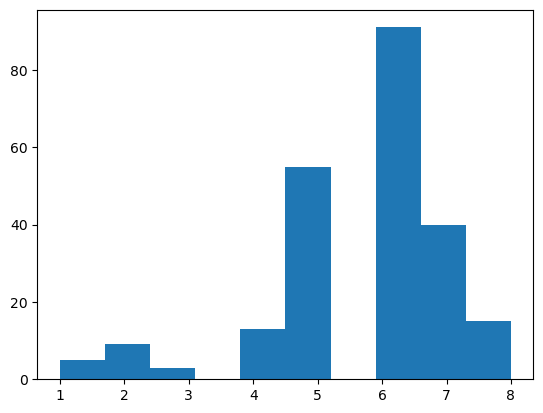

In [24]:
# still about half of the flightlines are left to be uploaded so will need to rereun this
tmp = out_table.groupby('plot_name')['flightline_id'].nunique().reset_index(name='flightline_id')
print(tmp.flightline_id.sum())
plt.hist(tmp.flightline_id)

In [25]:
# confirm final column data types

print(out_table.dtypes)

out_table.dtypes

plot_name               object
sample_date             object
geom                    object
acquisition_date        object
extraction_method       object
flightline_id           object
scene_id                object
raster_plot_event_id    object
dtype: object


plot_name               object
sample_date             object
geom                    object
acquisition_date        object
extraction_method       object
flightline_id           object
scene_id                object
raster_plot_event_id    object
dtype: object

In [26]:
# export table
fp_out = os.path.join(out_folder, f'{table}.csv')
out_table.to_csv(fp_out, index=False)